In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [13]:
df_train= pd.read_csv("p2-train.txt", sep="\t", header=None)
df_train.head(10)

,0,1
0,musikgeschichte,1
1,tesa,0
2,trabant,0
3,zachurisch,0
4,polybasit,0
5,annahme,0
6,walsertal,0
7,renminbi,0
8,studienassessor,1
9,verfassungsvertrag,1


In [14]:
df_train.columns = ["original_word", "is_compound"]
df_train

,original_word,is_compound
0,musikgeschichte,1
1,tesa,0
2,trabant,0
3,zachurisch,0
4,polybasit,0
...,...,...
8331,biografie,0
8332,sulawesi,0
8333,rechnung,0
8334,contest,0


In [23]:
df_test = pd.read_csv("p2-test.txt", sep="\t", header=None)
df_test.head(10)

,0
0,bücherbus
1,irritation
2,cc
3,nichtchrist
4,iran
5,karambole
6,jakutin
7,beatmungsgerät
8,espresso
9,sport


<Axes: title={'center': 'Distribution of Compound Words in Training Set'}, xlabel='is_compound'>

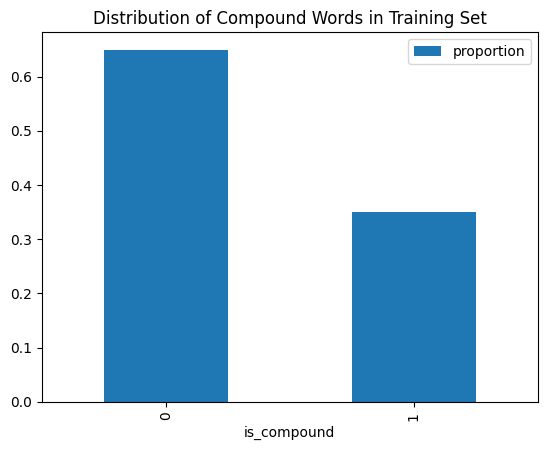

In [18]:
df_train["is_compound"].value_counts(normalize=True).plot(kind="bar", legend=True, title="Distribution of Compound Words in Training Set")

In [26]:
print(df_train['is_compound'].isna().sum())
print(df_train['original_word'].isna().sum())

print(df_test.isna().sum())

0
0
0    0
dtype: int64


In [27]:
%pip install -U scikit-learn
print("Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 20.3 MB/s  0:00:00m0:00:0100:01
  Attempting uninstall: scikit-learn━━━━━━━━━━━━ 0/2 [narwhals]
    Found existing installation: scikit-learn 1.8.032m0/2 [narwhals]
    Uninstalling scikit-learn-1.8.0:m╺━━━━━━━━━━━━━━━━━━━ 1/2 [scikit-learn]
      Successfully uninstalled scikit-learn-1.8.0━━━━━━━━━━━━━ 1/2 [scikit-learn]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Done


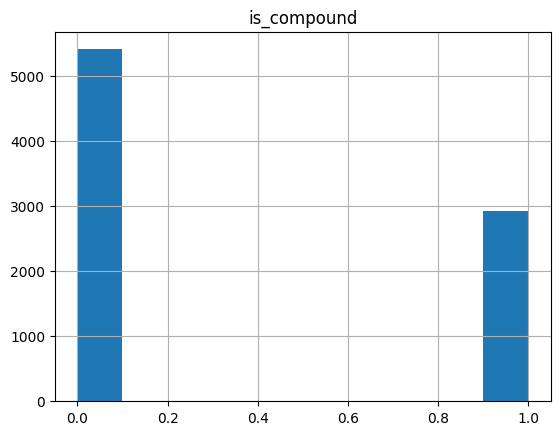

In [28]:
df_train.hist()

plt.show()

In [29]:
df_train.shape

(8336, 2)

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

#stratify true version

x_train, x_test, y_train, y_test = train_test_split(df_train["original_word"], df_train["is_compound"], test_size=0.2, random_state=42,
                                                    stratify=df_train["is_compound"])

print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

(6668,)
(1668,)
(6668,)
(1668,)


In [31]:
type(x_train)

pandas.Series

In [34]:
x_train.head(10)

7999      akademie
1388    pentateuch
4135    descloizit
1819    opposition
6997       galenit
2799     unihockey
6700        brummi
7643    interregio
1125      adeliger
442      hofkammer
Name: original_word, dtype: str

In [36]:
df_x_train= x_train.to_frame()
df_x_test= x_test.to_frame()

df_x_train.head(10)

,original_word
7999,akademie
1388,pentateuch
4135,descloizit
1819,opposition
6997,galenit
2799,unihockey
6700,brummi
7643,interregio
1125,adeliger
442,hofkammer


どうしてここでトレーニングした後のデータがデータフレームじゃなくてシリーズタイプになっているのかがわからない
これはサーキットランの仕業だと思っていたけど、違う

train_test_split(df_train["original_word"], df_train["is_compound"], test_size=0.2, random_state=42,
                                                    stratify=df_train["is_compound"])
ここの時点で[[original]]みたいな感じで提示すると、データフレームで返してくれる
1個だけだとシリーズのまま

使い分け方法
基本的に1列の生データがシリーズ
フレームは複数の特徴量が並んだモデルに投入する形、サンプル数×特徴量の数みたいな
# Series
Series (x_train) の状態:

| index | name: original_word |
|-------|---------------------|
| 0     | Kinderfahrradhelm   |
| 1     | Auto                |
| 2     | Hausmeister         |
...	...

shape: (6668,) — 1次元

# df
DataFrame (x_train_features) の状態:

| index | word_length | vowel_count | ends_with_ung |
|-------|-------------|-------------|---------------|
| 0     | 17          | 6           | 0             |
| 1     | 4           | 2           | 0             |
| 2     | 11          | 4           | 0             |

shape: `(6668, 3)` — 2次元、3列


Series を触っている間は「まだ加工中」
DataFrame にした瞬間から「モデル投入 ready」

In [ ]:
df_train_features = pd.DataFrame()


# length
def calc_len(df_word):
    """
    Input:
    Dataframe[['akademie'], ['pentateuch']]
    
    return:
    Dataframe with length
    [[len('A')],[len('B')],,,]
    
    """
    
    df_word_len = pd.DataFrame()
    

    df_word_len["length"] = df_word["original_word"].str.len()

    # .to_frame
    return df_word_len #data frame that is addible at end

# vowel amd vowel ration 
def calc_vowel_counts(df_word):
    # german_vowel = ["a", "e", "i", "o", "u", "ä", "ö", "ü"]
    
    df_word_vowel = pd.DataFrame()
    
    # df_word_vowel["Vowel_count"] = word["original_word"].str.lower()#これだと下のやつに上書きされる
    
    # df_word_vowel["Vowel_count"] = word["original_word"].str.count("[aeiouäöü]") #count only accept string
    df_word_vowel["Vowel_count"] = df_word["original_word"].str.lower().str.count("[aeiouäöü]") #count only accept string


    return df_word_vowel

def calc_vowel_ratio(df_word):
    
    df_v_ratio = pd.DataFrame()
    df_l = calc_len(df_word)
    df_v_count = calc_vowel_counts(df_word)

    
    df_v_ratio["vowel_ratio"] = df_v_count["Vowel_count"] / df_l["length"]
    
    return df_v_ratio

# heiphen

def is_hyphen(df_word):
    
    df_h=pd.DataFrame()
    
    df_h["is_hyphen"] = (df_word["original_word"].str.count("-") > 0).astype(int) #if -, then1
    
    return df_h

#add all function

def extract_features(df_data):
    
    df_len = calc_len(df_data)
    # df_vowel_count = calc_vowel_counts(df_data)
    df_vowel_ratio = calc_vowel_ratio(df_data)
    df_hyphen = is_hyphen(df_data)

    df_features = pd.concat([df_len,  df_vowel_ratio, df_hyphen], axis=1) #横に特徴量を結合

    return df_features


,length
7999,8
1388,10
4135,10
1819,10
6997,7


In [38]:
df_train_features = extract_features(df_x_train)
df_train_features

,length,vowel_ratio,is_hyphen
7999,8,0.625000,0
1388,10,0.400000,0
4135,10,0.400000,0
1819,10,0.500000,0
6997,7,0.428571,0
...,...,...,...
6202,8,0.250000,0
2747,6,0.500000,0
891,10,0.400000,0
1870,8,0.625000,0


In [40]:
df_test_features = extract_features(df_x_test)
df_test_features

,length,vowel_ratio,is_hyphen
2344,14,0.285714,0
7436,5,0.600000,0
4509,24,0.375000,0
8116,14,0.357143,0
538,8,0.375000,0
...,...,...,...
5501,8,0.375000,0
1205,11,0.363636,0
3731,8,0.375000,0
767,8,0.375000,0


Now finished extraction, move to training and modeling
extract_features take feature that is

Review Standardscaler z = (X −平均)÷標準偏差 各列ごとでやってくれる。 長さ列 母音率列 ハイフン列

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_x_scaled_train = scaler.fit_transform(df_train_features) #fitで平均、標準偏差Get Transformでスケーラーが覚えた平均と、標準偏差の値を使ってzをゲットする

df_x_scaled_test = scaler.transform(df_test_features)

df_x_scaled_train

array([[-0.28839328,  2.56024723, -0.08604029],
       [ 0.23175993,  0.28187526, -0.08604029],
       [ 0.23175993,  0.28187526, -0.08604029],
       ...,
       [ 0.23175993,  0.28187526, -0.08604029],
       [-0.28839328,  2.56024723, -0.08604029],
       [-0.54846989,  2.01777771, -0.08604029]], shape=(6668, 3))

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(df_x_scaled_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [43]:
y_pred = model.predict(df_x_scaled_test)
y_pred

array([1, 0, 1, ..., 0, 0, 1], shape=(1668,))

In [44]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred, average='macro')

0.8742765758030582

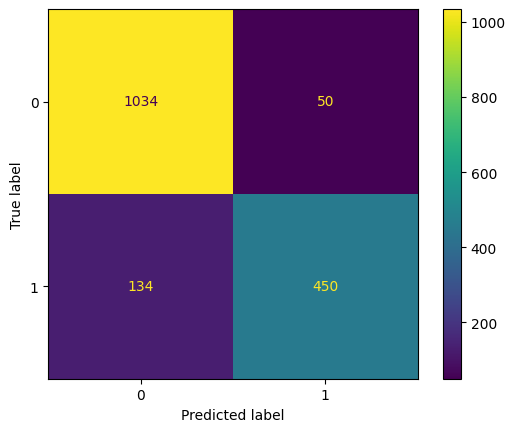

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. 混同行列の計算
cm = confusion_matrix(y_test, y_pred)

# 2. 混同行列の表示
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [46]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold


pipeline = Pipeline([
    ('scaler', StandardScaler(),),
    ('classifier', LogisticRegression())
])

#use train feature already extraxted agains 6668 cases
score = cross_val_score(pipeline, df_train_features, y_train, cv=StratifiedKFold(n_splits=5), scoring='f1_macro')

score

array([0.88965526, 0.87297271, 0.87500725, 0.86001986, 0.88765477])

In [47]:
pipeline.fit(df_train_features, y_train)

y_prediction = pipeline.predict(df_test_features)

print(y_prediction)

[1 0 1 ... 0 0 1]


In [48]:
confusion_matrix(y_test, y_prediction)


array([[1034,   50],
       [ 134,  450]])

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_prediction))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1084
           1       0.90      0.77      0.83       584

    accuracy                           0.89      1668
   macro avg       0.89      0.86      0.87      1668
weighted avg       0.89      0.89      0.89      1668



In [51]:
#reread again
df_p2_test = pd.read_csv("p2-test.txt", header=None, names=["original_word"])

#reextract featires
df_p2_test_features = extract_features(df_p2_test)

df_p2_test_features.head()

,length,vowel_ratio,is_hyphen
0,9,0.333333,0
1,10,0.500000,0
2,2,0.000000,0
3,11,0.181818,0
4,4,0.500000,0


In [52]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


from sklearn.model_selection import StratifiedKFold

from sklearn.model_selection import cross_val_score


pipeline = Pipeline([
    ('scaler', StandardScaler(),),
    ('classifier', LogisticRegression())
])

score = cross_val_score(pipeline, df_train_features, y_train, cv=StratifiedKFold(n_splits=5), scoring='f1_macro')
score

array([0.88965526, 0.87297271, 0.87500725, 0.86001986, 0.88765477])

In [53]:
#fit

pipeline.fit(df_train_features, y_train)

#predict with p2_testfeatures
updated_final_prediction = pipeline.predict(df_p2_test_features)

len(updated_final_prediction)

2000

In [54]:
with open('predictions.txt', 'wt') as fout:
    for p in updated_final_prediction:
        print(p, file=fout)

質問：
今回のアプローチであった自分なりのやつは言語Dependentではないものを意識しての結果だったけど、NgramもDependentにはならないよね？
コード行く前に、概念とどんな例として動いてるかパターンを見たい
イメージで行くと接頭辞・接尾詩とかがあると思うけど、これらをリストあらかじめしてからだとLangdependentになるよね？　なんでNgramが有用なのかまずはここから行きたい



とてもいい問いです。ここは面接でも "Why n-grams and not linguistic rules?" として聞かれる論点で、答え方を持っておく価値があります。

## まず結論

**N-grams は言語非依存 (language-independent)** です。あなたの直感は正しい。理由: 「文字列を n 文字ずつスライドさせて切る」というルールしか使っていないから。ドイツ語だろうと日本語だろうとフィンランド語だろうと、同じアルゴリズムで動きます。

対して、あなたが挙げた「接頭辞・接尾辞のリストを事前に用意する」アプローチは **言語依存 (language-dependent)** です。ドイツ語の `-ung, -heit, -keit` のリストを日本語に持って行っても意味がない。

## Character N-grams が何をしているか

「単語を **連続する n 文字** の断片に分割する」だけ。

例: `Kinderfahrradhelm` の character bigrams (n=2):

```
Ki, in, nd, de, er, rf, fa, ah, hr, rr, ra, ad, dh, he, el, lm
```

Character trigrams (n=3):

```
Kin, ind, nde, der, erf, rfa, fah, ahr, hrr, rra, rad, adh, dhe, hel, elm
```

`Auto` の bigrams なら:

```
Au, ut, to
```

こういう「文字の並びのかけら」を集めて、単語ごとに「どんな n-gram が何回出るか」を数える。それが特徴量になる。

## じゃあなぜ、ルール（-ung のリスト）ではなく n-gram なのか

ここが核心。理由は5つあります。

### 1. モデルが「勝手に発見してくれる」

`-ung` が複合語判定に効くという知識を、事前に人間が与える必要がない。

N-gram で全部の 2-3 文字の並びを feature 化すれば、その中に **`ung`, `hei`, `kei`** も自動的に含まれます。学習の過程で「`ung` を含む単語は複合語の確率が高い」ということを **モデルが重み w を通じて学ぶ**。

つまり n-gram は「言語学者の知識を feature engineering に閉じ込める」代わりに、「データからパターンを発見させる」アプローチ。

### 2. 網羅性

人間がリストを作ると、必ず抜けが出る。

`-ung, -heit, -keit` は思いつくけど、`-schaft, -tum, -nis, -er, -chen, -lein` はどうか？さらに複合語の境界に出やすい **中間の文字列** — 例えば `sfa` (`Wirtschaftsfach` の中の `sf` 部分) — なんて人間はまず思いつかない。

N-gram は **考えられる全パターンを機械的に生成する**。抜けがない。

### 3. 未知の pattern も captureできる

Training data に出てくる n-gram なら何でも feature になるので、「言語学的には未知だが統計的に有効」なパターンも拾える。

例: ドイツ語で `sch` は非常に頻出。もしかしたら `sch` が単語末尾に来る位置が複合語判定に効くかもしれない。人間はそんな仮説立てないけど、n-gram + logistic regression は自動的に「その組み合わせに重みをつけるべきか」を判断する。

### 4. Multilingual に転用できる

これがあなたの project の核心的なポイント。

`-ung` ベースの feature 抽出コードは日本語では動かない。でも character n-gram のコードは、**日本語の単語** `扇風機` に対してもそのまま動く:

```
扇風, 風機  (bigrams)
```

**同じコードで、ドイツ語も日本語も英語も特徴量化できる**。これが「多言語 NLP の土台」として n-gram が選ばれる理由の一つ。

Google の multilingual 検索、Facebook の言語判定モデル (fastText の language identification)、Unicode の subword tokenizer — これらは全部 character n-gram の考え方が根底にあります。

### 5. 未知語 (Out-of-Vocabulary) に強い

Training 時に見たことのない単語 `Rechtsschutzversicherung` が test に出てきたとき。

もし feature が「単語全体」なら未知語で終わり。でも n-gram なら、`Rec, ech, cht, hts, tss, ...` みたいに文字の断片に分解されて、そのうちのいくつかは training で見たことがある。だから **未知語でも部分的に判定できる**。

これは前に話した subword tokenization (BPE, WordPiece) の哲学と直接繋がっています。第2世代の semantic search で BERT が未知語に強いのも、同じ理由。

## トレードオフ: n-gram の弱点

公平のために言うと、n-gram にも欠点はあります:

**1. 高次元になる**

Bigram だけでも、language の文字数を N とすると理論上 N × N 個の feature が生まれる。ドイツ語のアルファベット (拡張含めて ~30) なら 900 個の bigram、trigram なら 27000 個。Sparse matrix で扱うので実務上は問題ないけど、次元は爆発的に増える。

**2. 意味を捉えていない**

`ung` という文字列は捕捉できるけど、それが「動作の名詞化を表す接尾辞」だという **意味的な情報** は持たない。単なる文字列。だから n-gram だけでは限界がある。

**3. 順序情報が失われる**

`Bag of n-grams` として集計するので、単語内の位置情報 (単語頭にあるか末尾にあるか) が消える。これに対処するために、位置情報つきの feature を追加したり、あるいは sequence model (RNN, Transformer) に進むことになる。

## Level 2 でやろうとしていること

前の話に戻すと、Level 0, 1 は言語知識ベース (word length, vowel count, suffix)、Level 2 で n-gram に移行する、という設計でした。

これは実は portfolio 的にも綺麗な流れです。面接で:

> "I started with linguistically-motivated features to establish a baseline, then moved to character n-grams to make the approach **language-agnostic** and to let the model discover patterns rather than hand-coding them. This is the same principle that underlies subword tokenization in modern LLMs."

と語れる。

## Next action

コードに入る前に、あなた自身の言葉で答えられるか test してみますか?

- "Why do you use character n-grams instead of a suffix list?"
- "How is this related to subword tokenization in BERT?"
- "What's a weakness of n-gram features?"

もし詰まったら深掘りできるし、答えられたら実装に進みましょう。

質問：
Ngramは単語に対して、分解がLang dependentにならないままで行けるいいツール。だから未知の単語に対しても対応できるけど、今回のタスクに関していえば、複数形になればこういう接頭辞が多いよねってのがどう見えてくるの？リストのカウント？それともモデルに流す特徴？



すごく核心を突く質問です。ここが分かると n-gram + logistic regression の全体像がクリアになります。

## 結論を先に

**「-ung が複合語判定に効く」という発見は、モデルが学習した重み w の中に現れる**。リストのカウントではなく、モデルに流す特徴として入れて、モデルが「その特徴が正解と相関しているか」を勝手に見つける。

順を追って説明します。

## Step 1: N-gram を全部列挙して特徴量にする

まず training data の全単語から、出現する n-gram を **全部集める**。これが vocabulary になります。

例えば training data に 5000 個の単語があって、そこから抽出された unique な bigram + trigram が 3000 種類あったとします。

これで **3000 個の feature の枠** ができる。あなたが「これが効きそう」と選ぶわけではなく、全部並べる。

```
feature 0: "un"
feature 1: "ng"
feature 2: "ung"    ← 人間から見ると重要そう
feature 3: "he"
feature 4: "ei"
feature 5: "hei"    ← これも重要そう
...
feature 2847: "xz"  ← ほぼゼロだけど枠だけある
...
feature 2999: 何か
```

## Step 2: 各単語を「どの n-gram を含むか」のベクトルに変換

`Zeitung` (新聞、非複合語) を例にすると:

```
bigrams:  Ze, ei, it, tu, un, ng
trigrams: Zei, eit, itu, tun, ung
```

これを 3000 次元のベクトルにすると:

| feature | 含まれる? |
|---|---|
| "un" | 1 |
| "ng" | 1 |
| "ung" | **1** |
| "he" | 0 |
| "ei" | 1 |
| "hei" | 0 |
| ... | ... |

つまり `Zeitung` は `[0, 1, 1, 1, 0, 1, 0, ...]` みたいな 3000 次元のスパースベクトル。

`Kinderfahrradhelm` (複合語) だと、`ung` の位置は 0 だけど、他のたくさんの位置が 1 になる。

同様に全 5000 単語について 3000 次元のベクトルを作る。これで **5000 × 3000 の特徴量行列 X** が完成。

## Step 3: モデルに X と y を渡す

```python
X.shape  # (5000, 3000)
y.shape  # (5000,)  ← 各単語が複合語か (0 or 1)
```

Logistic regression はこれを見て、3000 個の重み w を学習する:

$$z = w_0 \cdot x_0 + w_1 \cdot x_1 + w_2 \cdot x_2 + \dots + w_{2999} \cdot x_{2999} + b$$

## Step 4: 学習後の w にパターンが現れる

学習が終わったあと、モデルの重み `w` を見てみると、こんな感じになっているはずです:

| feature | w の値 | 解釈 |
|---|---|---|
| "ung" | **+2.3** | この n-gram があると「複合語」の確率が上がる |
| "hei" | +1.8 | 同上 |
| "sch" | +1.2 | 同上 |
| "xy" | -0.01 | ほぼ効いていない |
| "au" | -0.5 | むしろ非複合語の signal |

**この重みが「-ung が効く」の実体です。**

つまり:
- 事前に人間が `["ung", "heit", "keit"]` というリストを作ってカウントしたわけではない
- 全 n-gram を平等に feature として並べて、モデルが「どれが正解と相関しているか」を data から発見した
- 発見の結果が **重み w の値** として現れる

## 面白いのは、モデルは言語学を知らないこと

モデルは `ung` が「動作の名詞化を表すドイツ語の接尾辞」だと知らない。ただ「training data で `ung` を含む単語は複合語ラベルと統計的に相関している」というパターンを見つけただけ。

でも結果として、言語学者が手作業で作るリストと **同じような、あるいはそれ以上に精密な** 特徴発見ができる。しかも:

- 人間が思いつかない n-gram（例えば `sfa` みたいな複合語の境界に現れる文字列）も自動で拾える
- 別の言語に切り替えても、同じアルゴリズムが動く

## リストのカウントとの明確な違い

もしあなたが Level 1 でやったような手作りアプローチだと:

```python
suffixes = ['ung', 'heit', 'keit', 'schaft']
x_train_features['num_matching_suffixes'] = x_train.apply(
    lambda w: sum(w.endswith(s) for s in suffixes)
)
```

これは **1つの feature (0 か 4 の間の整数)** になる。事前に人間が選んだリスト、位置は末尾限定。

N-gram アプローチだと **3000 個の feature (それぞれ 0 か 1)**。全パターン、位置制限なし。

## 学習後に「何が効いたか」を見る方法

面接でも聞かれるし、あなた自身のためにも見ておく価値があります:

```python
# モデル学習後
feature_names = vectorizer.get_feature_names_out()
weights = model.coef_[0]

# 重みが大きい順に並べる = 複合語の signal が強い n-gram
top_positive = sorted(zip(feature_names, weights), key=lambda x: -x[1])[:20]
top_negative = sorted(zip(feature_names, weights), key=lambda x: x[1])[:20]

for name, w in top_positive:
    print(f"{name}: {w:.3f}")
```

これで「モデルが何を学んだか」を人間が読める形で確認できる。多分 `ung`, `hei`, `sch`, `keit` みたいなドイツ語の学者が知っている接尾辞パターンが、上位に自動で現れます。

これは面接で見せると強い。「モデルが自分で言語学的に妥当な pattern を発見しました」というストーリーになる。

## つまり全体のフロー

```
[全 n-gram を機械的に列挙]  ← vectorizer.fit()
         ↓
[各単語 → n-gram の有無ベクトル (0/1 の 3000次元)]  ← vectorizer.transform()
         ↓
[X (5000×3000) + y (5000,) をモデルに渡す]  ← model.fit()
         ↓
[モデルが 3000 個の重み w を学習]
         ↓
[w の値を見ると「どの n-gram が複合語 signal か」がわかる]  ← insight
```

**「-ung が効く」という知識は、事前の feature ではなく、学習後の重みの中に現れる**。これが n-gram + logistic regression の真髄です。

コードに進む準備はできましたか?

Ngramに関して基礎知識としてはおさえたけど、現場とクラスにおいて、Ngramはライブラリとかつかってる？
今はもう使われてない？RAGとかIRとかにおいても？

「LLMやTransformerがこれだけ騒がれている今、N-gramなんてもう古いのでは？」と疑問に思うのは、非常に自然で鋭い視点です。

結論から言うと、N-gramは「文章を生成する主役」の座からは完全に降りましたが、**検索エンジン（IR）やRAGの土台、そしてLLMの裏方として、現場では今でもゴリゴリに使われています。**

応用AIエンジニアとして実務に出た際、N-gramがどこで、どんなライブラリと共に生き残っているのか、具体的なリアルをお伝えします。

### 1. 検索（IR）とRAGにおける「最強のセーフティネット」

RAGの精度を高めるための現在の業界標準は、意味を捉える「ベクトル検索」と、単語の一致を捉える「キーワード検索」を組み合わせた**ハイブリッド検索**です。このキーワード検索の裏側でN-gramが大活躍しています。

* **スペルミスと部分一致（Edge N-gram）:**
ユーザーが検索窓に「Pytho」まで打った時のオートコンプリートや、「テンプロ大学」と打ち間違えた時に「テンプル大学」をヒットさせるような曖昧検索は、文字単位のN-gramの得意分野です。
* **日本語とドイツ語の壁を越える:**
MeCabやspaCyのような高度な形態素解析ツールは、辞書にない未知語や新しい造語が出ると単語の分割に失敗（検索漏れ）を起こします。これを防ぐため、現場の検索エンジン（Elasticsearchなど）では、「とりあえず文字を2文字ずつ区切って検索インデックスを作る（Bi-gramインデックス）」という泥臭い手法が、日本語処理の鉄板として現在も使われています。ドイツ語の長大な複合語も、N-gram的なアプローチで部分文字列としてヒットさせる工夫が不可欠です。

### 2. LLMの根幹を支える「サブワード」の概念

今のLLM（ChatGPTやClaudeなど）は、入力されたテキストを単語でも文字でもなく、「サブワード（単語のパーツ）」に分割して処理しています。
このサブワードの辞書を作るアルゴリズム（BPEやWordPieceなど）は、「コーパスの中で一緒に出現する頻度が高い文字の連続（まさにN-gramの考え方）をくっつけて一つのトークンにする」という仕組みで動いています。N-gramの統計的な発想がなければ、現代のLLMは存在しません。

### 3. 現場やクラスで使われる具体的なライブラリ

プロジェクトや実務でN-gramを扱う場合、ゼロからコードを書くことは少なく、以下のライブラリを叩くのが一般的です。

* **`scikit-learn` (`CountVectorizer` / `TfidfVectorizer`):**
機械学習の超定番。パラメータに `ngram_range=(1, 3)` と入れるだけで、Unigram（1単語）からTrigram（3単語）までの特徴量を一発で行列化してくれます。テキスト分類やベースラインモデルの構築で必ず使います。
* **Elasticsearch (Lucene):**
世界中で最も使われている検索エンジン基盤。設定ファイル（Mapping）の中で「この日本語のテキストフィールドは、N-gram（Bi-gram）で処理してね」と指定するだけで、裏側で自動的にインデックスを作ってくれます。
* **FastText (Meta/Facebook):**
単語をさらに「文字のN-gram」に分解して学習する手法。これにより、トレーニングデータに存在しなかった未知語や、ドイツ語の複雑な複合語に対しても、N-gramのパーツから「意味のベクトル」を推測できるため、実務で非常に重宝されます。

- 曖昧さをあえて出す為の技術があるのが面白い。UX向上
- 検索アルゴリズムとのコンビネーションでどうElastic searchとかとくっつくか気になる。

---

このように、N-gramは決して過去の遺物ではなく、言語の壁や表記ゆれを吸収するための「強力な配管工事のツール」として、応用エンジニアの必須の引き出し（ドメイン知識）となっています。

これから作る「アニメセリフの検索＆キャラクター特性分析エンジン」などのMVPにおいて、`scikit-learn`を使ってN-gramとTF-IDFを組み合わせた古典的な検索を組み込み、最新のベクトル検索と精度を比較してみるアプローチには興味はありますか？

# Countvectorの裏側の質問

Ngramでリストが出来上がっていくよね？このときのフローは？単語読む、分解する。リスト追加する。それを３００単語なら全部する

そしてもう一周して単語一個のなかにあったか確認の２周目？でないとSParseなべくとるにならないよね？AutoがくるAu ut toになる　次の単語行く　全部単語まわると何が選択肢として手元に来るかがわかる。それを２周目でマージしてからいって、Auto２回目出てきたらAu ut toを１回ずつ追加みたいな？


その 2-pass の理解、完全に正しいです。そしてこれが前に話した **fit と transform のルール** にそのまま繋がります。

## あなたの直感 = fit と transform

- **Pass 1 (vocabulary 構築)** = `vectorizer.fit(x_train)`
- **Pass 2 (各単語をベクトル化)** = `vectorizer.transform(x_train)`
- **両方まとめて** = `vectorizer.fit_transform(x_train)`

つまりあなたが2周目と呼んでいる処理が、まさに `transform` の中身です。

## ミニ例で追ってみる

Training data が 3 単語だとしましょう:

```
Auto
Ausflug
Kinderfahrrad
```

### Pass 1: vocabulary を作る (bigram で)

各単語を分解:

```
Auto        → Au, ut, to
Ausflug     → Au, us, sf, fl, lu, ug
Kinderfahrrad → Ki, in, nd, de, er, rf, fa, ah, hr, rr, ra, ad
```

出現した bigram を全部集めて重複を排除、ソート:

```
vocabulary = [ad, ah, Au, de, er, fa, fl, hr, in, Ki, lu, nd, ra, rf, rr, sf, to, ug, us, ut]
                                                                                        (20個)
```

これが手元に残る「選択肢のリスト」。**あなたの言う「1周目の結果」がこれ**。

### Pass 2: 各単語を 20 次元ベクトルに変換

vocabulary の順番に沿って、「その bigram が単語に含まれるか、あるいは何回含まれるか」を書き込んでいく:

| 単語 | ad | ah | Au | de | er | fa | fl | hr | in | Ki | lu | nd | ra | rf | rr | sf | to | ug | us | ut |
|---|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|-|
| Auto | 0 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 1 |
| Ausflug | 0 | 0 | 1 | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 0 | 1 | 0 | 1 | 1 | 0 |
| Kinderfahrrad | 1 | 1 | 0 | 1 | 1 | 1 | 0 | 1 | 1 | 1 | 0 | 1 | 1 | 1 | 1 | 0 | 0 | 0 | 0 | 0 |

これが **shape (3, 20) の Sparse ベクトル**。あなたが「2周目でマージしていく」と言っていた処理そのもの。

## Count vs Binary の話

あなたが最後に「Auto が2回目出てきたら Au ut to を1回ずつ追加」と書いていた部分、これは **同じ単語内での重複** の話と **異なる行の話** に分けて考える必要があります。

**同じ行 (単語) の中で bigram が複数回出る場合**:

例えば `Banana` を bigram で分解すると `Ba, an, na, an, na`。ここで `an` と `na` が2回ずつ出てくる。

- `CountVectorizer` (default) → その回数を数える。`an` の列に `2` が入る
- `CountVectorizer(binary=True)` → 出たか出ないかだけ。`an` の列に `1` が入る

複合語判定タスクなら実は `binary=True` の方が向いていることが多いです。同じ n-gram が何回出るかより「そもそも含まれているか」が重要だから。

**異なる行 (単語) にまたがる場合**:

Training data に `Auto` が2回出てきたら、それは **別々の行として2行分計上される** だけ。同じ行の中でカウントが増えるわけではない。

## 実装上は 1 行で済む

sklearn がこの全 2-pass を裏でやってくれます:

```python
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(analyzer='char', ngram_range=(2, 3), binary=True)

x_train_ngram = vectorizer.fit_transform(x_train)  # Pass 1 + Pass 2
x_test_ngram = vectorizer.transform(x_test)         # test には train で作った vocabulary を使う (Pass 2 のみ)
```

`x_train_ngram.shape` を見ると `(6668, 数千)` みたいな 2次元 Sparse matrix になっているはず。

## 大事なポイント: なぜ test には fit しないか

前に一度話した話と全く同じ。

**train で作った vocabulary を、test でもそのまま使う** のがルール。もし test 側で新しく vocabulary を作り直したら、train と test で feature の並びが違ってしまって、モデルが何を見ているかわからなくなる。

もし test に `Rechtsschutzversicherung` という単語があって、その中の bigram `hu` が training data に一度も出てこなかった場合、`hu` は vocabulary に無いので **無視される**。これは feature 側の未知語問題ですが、n-gram なら他の bigram で部分的にカバーされるので、丸ごと失敗はしません。

## つまり全体像

あなたの理解を整理するとこう:

1. **Pass 1**: 全 training 単語を分解して、出現した n-gram を全部集める → vocabulary 完成
2. **Pass 2**: 各単語について、vocabulary の各 n-gram が含まれるか (or 何回含まれるか) をチェック → sparse ベクトル完成
3. これを y と一緒に logistic regression に渡すと、モデルが各 n-gram の重み w を学習する
4. Test では **同じ vocabulary** を使って、また Pass 2 だけをやる




In [57]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(analyzer='char', ngram_range=(2, 3), binary=True)

x_train_ngram = vectorizer.fit_transform(x_train)  # Pass 1 + Pass 2
x_test_ngram = vectorizer.transform(x_test)         # test には train で作った vocabulary を使う (Pass 2 のみ)

print(x_train_ngram.shape)


(6668, 6296)


# CountvectorでなでRangeをとるの？
NgramRangeってのは２から３Gramをやってるのはわかるけどこれはリストがごちゃまぜにならない？こっちの方が実用的？

いい質問。「ごちゃまぜにならないか」の直感は正しくて、確かに **全部混ざった1つの vocabulary** になります。でもそれは問題ではなく、むしろ狙いです。

## 何が起きているか

`ngram_range=(2, 3)` は「bigram と trigram の両方を feature にする」という意味。

`Auto` を例にすると:

```
bigrams (n=2):  Au, ut, to
trigrams (n=3): Aut, uto
```

Vectorizer は **全部を1つの vocabulary** に放り込みます:

```
vocabulary = [Au, ut, to, Aut, uto, ...]
              ↑ bigram      ↑ trigram
              が混ざっている
```

そして feature 行列も、bigram の列と trigram の列が並んで1つの行列になる:

| 単語 | Au | ut | to | Aut | uto | ... |
|---|---|---|---|---|---|---|
| Auto | 1 | 1 | 1 | 1 | 1 | ... |

## なぜこれで問題ないか

モデルは「これは bigram、これは trigram」という区別を **気にしない**。モデルから見れば全部「文字列 feature」であって、それぞれ独立に「複合語との相関」を学習するだけ。

そして重要なことに、bigram と trigram は **違う情報を持っている**:

- **Bigram** (`ng`) — 短くて、多くの単語に出現 → 一般的なパターン
- **Trigram** (`ung`) — 長くて、より特定的 → 「動詞の名詞化接尾辞」のような意味のあるパターン
- **4-gram** (`ungs`) — さらに特定的 → 「複合語の連結部分」に出やすい (`Wohnungsschlüssel` の `ungs`)

これらは競合ではなく **補完** し合う。モデルはどれが effective かを重み w で判別する。

## 実用性の話

「こっちの方が実用的?」の答え: **はい、range を持たせるのがほぼ default です**。

理由:
- **単一 n だと硬直的**: bigram だけだと粗すぎ、5-gram だけだと sparse すぎ
- **range を持たせると柔軟**: 短い頻出パターンと長い特徴的パターンの両方をモデルに与えられる
- **モデルが自動で選別**: どの n が効くかを重みで決めてくれる

実務でよく使われる range:
- `(2, 3)` — 軽量、baseline に
- `(2, 4)` — バランス
- `(3, 5)` — subword tokenizer 的、長めのパターン重視
- `(1, 1)` — unigram のみ (word tokenizer 相当)

あなたが今 `(2, 3)` でやっているのは妥当な選択。あとで `(2, 4)` や `(2, 5)` に変えて F1 がどう変わるか見るのも良い実験になります。

## 罠: 次元が爆発する

`ngram_range=(2, 5)` にすると feature 数が数万〜十数万になることがあります。Sparse matrix で扱っているので memory はそこまで問題にならないけど、学習時間は延びる。

もし次元を確認したければ:

```python
print(x_train_ngram.shape)
# 例: (6668, 45231)  ← ngram_range=(2, 5) だとこれくらいになる
```

これが極端に大きい場合、`min_df=2` (2回以上出た n-gram だけ残す) や `max_features=10000` (上位頻出のみ) で絞ることができます。

## つまり

- Bigram と trigram が混ざるのは仕様、問題なし
- モデルは種別を気にせず、それぞれの重みを独立に学習
- Range を持たせるのが実用的な default
- 次元が大きすぎたら `min_df` や `max_features` で調整



In [ ]:
#Ngramとして動いているかの確認
print(vectorizer.get_feature_names_out()[:30])


["'a" '-a' '-ad' '-am' '-an' '-b' '-be' '-bi' '-bü' '-c' '-co' '-d' '-di'
 '-do' '-du' '-dy' '-e' '-el' '-er' '-eu' '-f' '-fi' '-fo' '-fr' '-fü'
 '-j' '-ja' '-k' '-ko' '-l']


# なんでNgramなのに'a', '-ad'が？
鋭い観察。両方とも興味深い現象で、`CountVectorizer` の default 挙動が絡んでいます。

## `'a` の正体

これは unigram ではなく **bigram** です。`'` (apostrophe) と `a` の2文字。

Training data に `d'Auto` みたいな **apostrophe を含む単語** があると、それを `character` 単位で分解した時に `d'`, `'A`, `Au`, ... のような bigram が生まれます。

## `-a` `-ad` の正体

同じく、bigram の `-a` と trigram の `-ad`。ハイフンを含む単語が training data にあるからです。ドイツ語だと `-` を含む複合語がよくあります:

```
Nord-Ost-Passage
US-Wahl
Prof.-Dr.-Müller
```

これを character 単位で分解すると、ハイフンを含む n-gram が自然に生まれる。

## つまり両方とも n-gram として正しい

- `'a` = bigram (2文字)
- `-a` = bigram (2文字)
- `-ad` = trigram (3文字)

あなたが想定していた「n-gram はアルファベットだけで構成される」というモデルではなくて、`CountVectorizer(analyzer='char')` は **すべての文字 (記号含む) を平等に扱う** のが default です。

## sklearn がアルファベット順ソートする時の並び

ASCII コード順に並びます:

```
記号 ('  -  .) → 大文字 (A B C) → 小文字 (a b c)
```

だから vocabulary の最初に `'` や `-` で始まる n-gram が集まる。次に `A` `B` などで始まるもの、最後に小文字。

`ngram_range=(2, 3)` なら、長さ 2 と 3 の n-gram の合計が total と一致するはず。これが確認できれば n-gram は完全に正しく動いている証拠です。

## 実務的な補足: 記号を除きたい時

もし「記号を含む n-gram はノイズだから除きたい」と思ったら、`token_pattern` や preprocessor でフィルタできます。でも今回の複合語判定タスクだと、**ハイフンは複合語の signal になる可能性がある** (例: `Nord-Ost` は複合語) ので、残しておいた方がむしろ有利かもしれません。

Level 2 の実験結果で「ハイフンありの n-gram の重みが大きい」ことが確認できたら、それも面接ネタになる。

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(x_train_ngram, y_train)

y_pred = model.predict(x_test_ngram)

print(f"F1: {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

F1: 0.8664
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1084
           1       0.91      0.83      0.87       584

    accuracy                           0.91      1668
   macro avg       0.91      0.89      0.90      1668
weighted avg       0.91      0.91      0.91      1668

Confusion matrix:
[[1036   48]
 [ 101  483]]


## Week 1 Results

| Approach | F1 (compound) | Notes |
|---|---|---|
| Random baseline | ~0.50 | |
| Level 1 (word length + vowel count + suffix) | ? | 手作り feature |
| Level 2 (char n-gram 2-3) | ~0.87 | Language-agnostic |
| Previous Lasso (from SNLP1) | 0.88 | For reference |

### Key insight
- Language-agnostic n-gram approach matched the performance of hand-crafted linguistic features
- False Negatives (missed compounds) > False Positives, suggesting the model is conservative
- Same approach could apply to Japanese/other languages without modification